In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from tqdm import tqdm

In [3]:
df = pd.read_csv('Exam_2026_Prob1.txt', sep=' ', header=None, names=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
df

,x1,x2,x3,x4,x5,x6
0,7.076218,0.083584,4.0,1.212479,2.470023,1.740495
1,6.182521,0.810306,4.0,1.151079,2.023988,7.642150
2,6.680523,0.857215,6.0,1.106831,1.136348,-0.798234
3,6.467101,0.222412,6.0,1.101607,2.469432,0.421692
4,6.320712,0.189092,4.0,1.111395,0.732828,1.676644
...,...,...,...,...,...,...
4116,6.188588,0.897227,1.0,1.096528,0.993603,0.418027
4117,6.041560,0.892445,7.0,1.192016,0.980775,6.964994
4118,8.616117,0.182497,9.0,1.119295,1.011689,6.066669
4119,7.370410,0.725753,8.0,1.052179,0.392890,2.661567


In [4]:
x1 = df['x1'].values
x3 = df['x3'].values
x4 = df['x4'].values

In [5]:
def f1(x, a):
    return 1/(x+5)*np.sin(a*x)

def f2(x, a):
    return np.sin(a*x)+1

def f3(x, a):
    return np.sin(a*x**2)

def f4(x, a):
    return (np.sin(a*x+1))**2

def f5(x):
    return x*np.tan(x)

def f6(x, a, b):
    return 1 + a*x + b*(x**2)

def f7(x, a):
    return 5 + a*x

def f8(x, a, b, c):
    return np.sin(a*x) + c*np.exp(b*x) + 1

def f9(x, a, b):
    return np.exp(-(x-a)**2/(2*b**2))



from scipy.stats import binom, poisson, logser

def f10(k, n, p):
    return binom.pmf(k, n, p)

def f11(k, lamb):
    return poisson.pmf(k, lamb)

def f12(k, p):
    return logser.pmf(k, p)

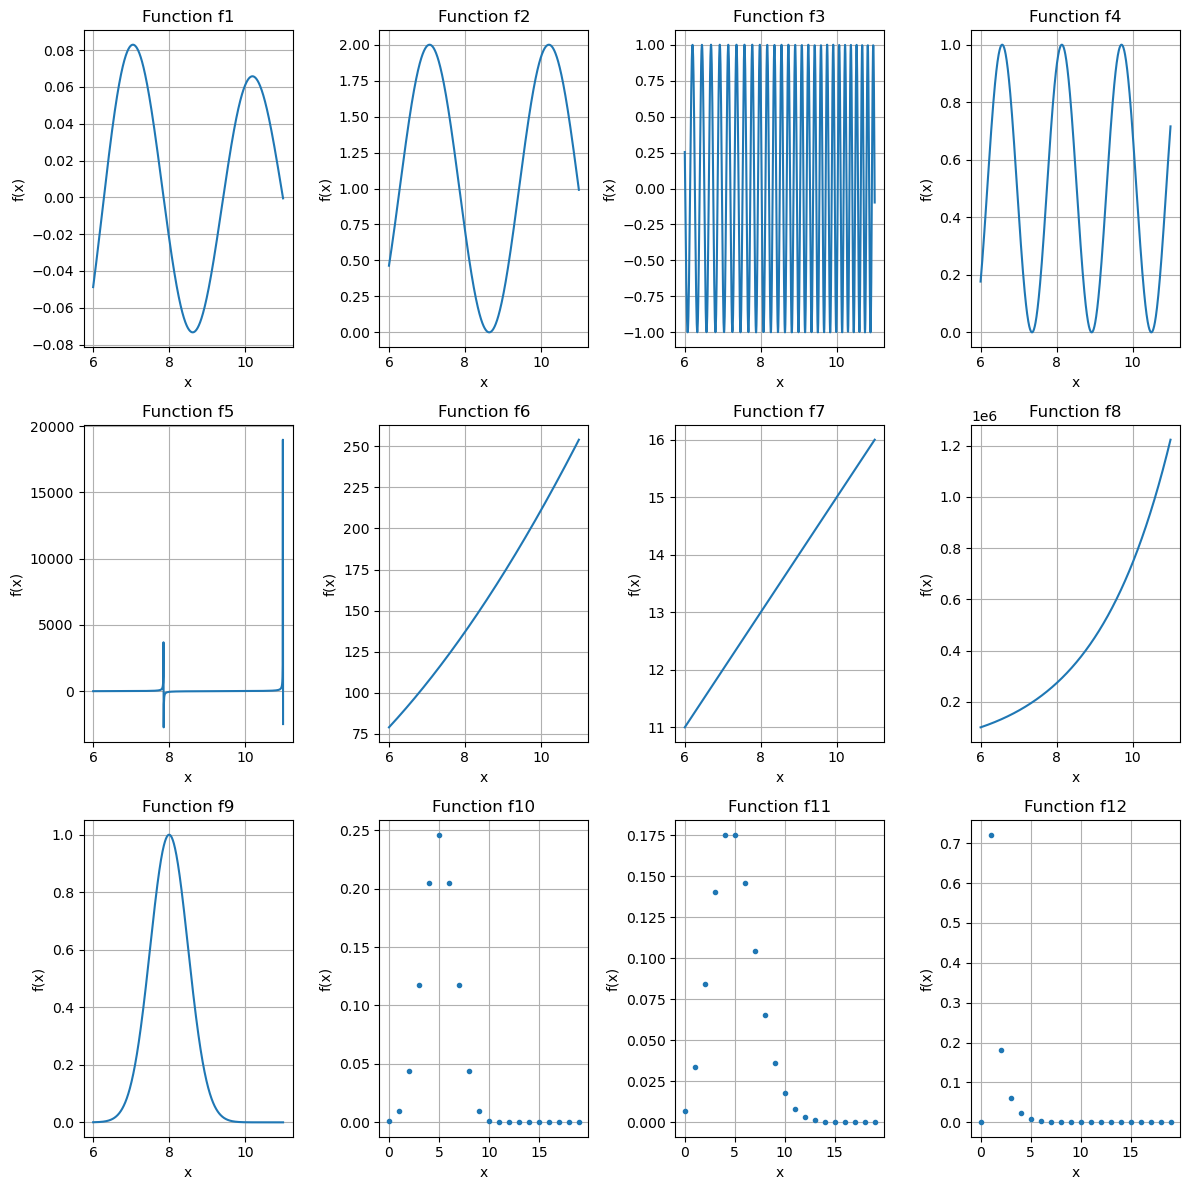

In [6]:
xxCont = np.linspace(6, 11, 1000)
xxDisc = np.arange(0, 20)
configs = [
    (f1, xxCont, (2,), '-'),
    (f2, xxCont, (2,), '-'),
    (f3, xxCont, (2,), '-'),
    (f4, xxCont, (2,), '-'),
    (f5, xxCont, (), '-'),
    (f6, xxCont, (1, 2), '-'),
    (f7, xxCont, (1,), '-'),
    (f8, xxCont, (0, 0.5, 5000), '-'),
    (f9, xxCont, (8, 0.5), '-'),
    (f10, xxDisc, (10, 0.5), '.'),
    (f11, xxDisc, (5,), '.'),
    (f12, xxDisc, (0.5,), '.'),
]

fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

for i, (f, x, args, style) in enumerate(configs):
    y = f(x, *args)
    ax[i].plot(x, y, style)
    ax[i].set_title(f'Function f{i+1}')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('f(x)')
    ax[i].grid()


plt.tight_layout()

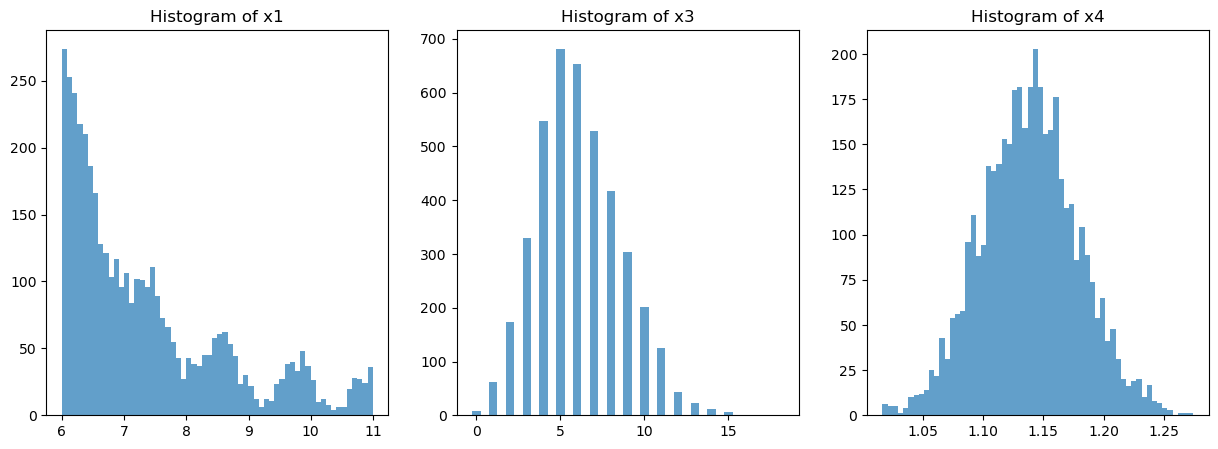

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(x1, bins=60, alpha=0.7)
ax[0].set_title('Histogram of x1')

ax[1].bar(np.unique(x3), np.unique(x3, return_counts=True)[1], width=0.5, alpha=0.7)
ax[1].set_title('Histogram of x3');

ax[2].hist(x4, bins=60, alpha=0.7)
ax[2].set_title('Histogram of x4');

In [8]:
np.min(x4), np.max(x4)

(np.float64(1.016642), np.float64(1.274252))

In [9]:
def raster_scan(cost_func, param_ranges, num_points=100):
    param_names = list(param_ranges.keys())
    n_params = len(param_names)

    grids = [np.linspace(*param_ranges[name], num_points) for name in param_names]

    # 1D scan
    if n_params == 1:
        values = np.array([cost_func(v) for v in grids[0]])/2

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grids[0], values, color='steelblue')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel('Cost function value')
        ax.set_title(f'Raster Scan — {param_names[0]}')

        best_idx = np.nanargmin(values)         
        best_x   = grids[0][best_idx]
        best_val = values[best_idx]
        ax.axvline(best_x, color='red', ls='--',label=f'Scan min: {param_names[0]} = {best_x:.3f} (NLL={best_val:.2f})')
        ax.legend();

    # 2D scan 
    if n_params == 2:
        g0, g1 = np.meshgrid(grids[0], grids[1])
        points  = np.vstack([g0.ravel(), g1.ravel()]).T
        values  = np.array([cost_func(p[0], p[1]) for p in points]).reshape(g0.shape)/2

        fig, ax = plt.subplots(figsize=(8, 6))
        pcm = ax.pcolormesh(g0, g1, values, cmap='plasma', shading='auto')
        plt.colorbar(pcm, ax=ax, label='Cost function value')

        flat_idx  = np.nanargmin(values)                         
        best_idx  = np.unravel_index(flat_idx, values.shape)      
        best_x    = g0[best_idx]
        best_y    = g1[best_idx]
        best_val  = values[best_idx]
        ax.plot(best_x, best_y, 'r*', ms=14, label=f'Scan min: ({best_x:.3f}, {best_y:.3f})  NLL={best_val:.2f}')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel(param_names[1])
        ax.set_title('Raster Scan — ' + ' vs '.join(np.flipud(param_names)))
        ax.legend();

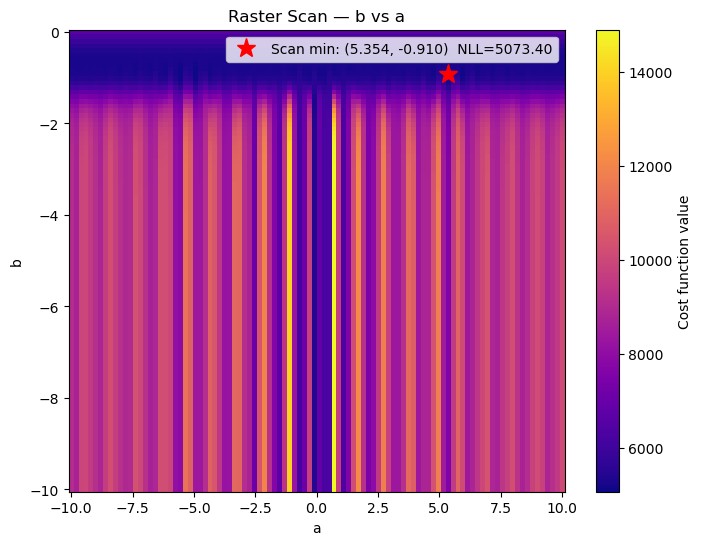

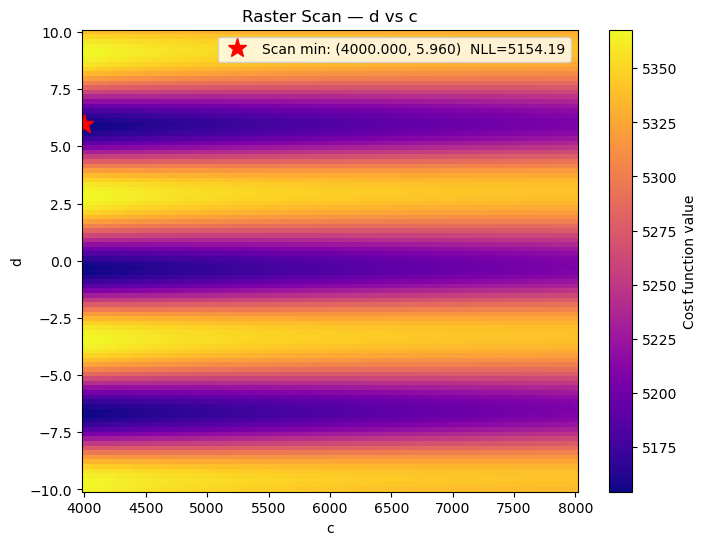

In [10]:
from scipy.integrate import quad
def f8New(x, a, b, c, d):
    return np.sin(a*x+d) + c*np.exp(b*x) + 1

def f8_norm(x, a, b, c, d):
    N = quad(lambda t: f8New(t, a, b, c, d), 6, 11)
    return f8New(x, a, b, c, d)/N[0]

def f8_fixed_cd(x, a, b):
    return f8_norm(x, a, b, 4000, 6)
c_cdfixed = cost.UnbinnedNLL(x1, f8_fixed_cd)
raster_scan(c_cdfixed, {'a': (-10,10), 'b': (-10, -0.001)}, num_points=100);

def f8_fixed_ab(x, c, d):
    return f8_norm(x, 4.693, -0.826, c, d)
c_abfixed = cost.UnbinnedNLL(x1, f8_fixed_ab)
raster_scan(c_abfixed, {'c': (4000, 8000), 'd': (-10, 10)}, num_points=100);

In [11]:

c1 = cost.UnbinnedNLL(x1, f8_norm)
m1 = Minuit(c1, a=4.7, b=-0.8, c=4000, d=6.4)

m1.limits['a'] = (-10, 10)
m1.limits['b'] = (-10, 10)
m1.limits['c'] = (4000, 8000)
m1.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.012e+04                  │              Nfcn = 263              │
│ EDM = 3.23e-05 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   5.29    │   0.05    │            │            │   -10   │   10    │       │
│ 1 │ b    │  -0.986   │   0.029   │            │            │   -10   │   10    │       │
│ 2 │ c    │   5.2e3   │   0.9e3   │            │            │  4000   │  8000   │       │
│ 3 │ d    │    0.1    │    0.5    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────────────┐
│   │        a        b        c        d │
├───┼─────────────────────────────────────┤
│ a │  0.00248   0.1e-3  -0.5956  -0.0231 │
│ b │   0.1e-3 0.000847 -25.1166  -0.7e-3 │
│ c │  -0.5956 -25.1166 8.49e+05     6.07 │
│ d │  -0.0231  -0.7e-3     6.07    0.219 │
└───┴─────────────────────────────────────┘

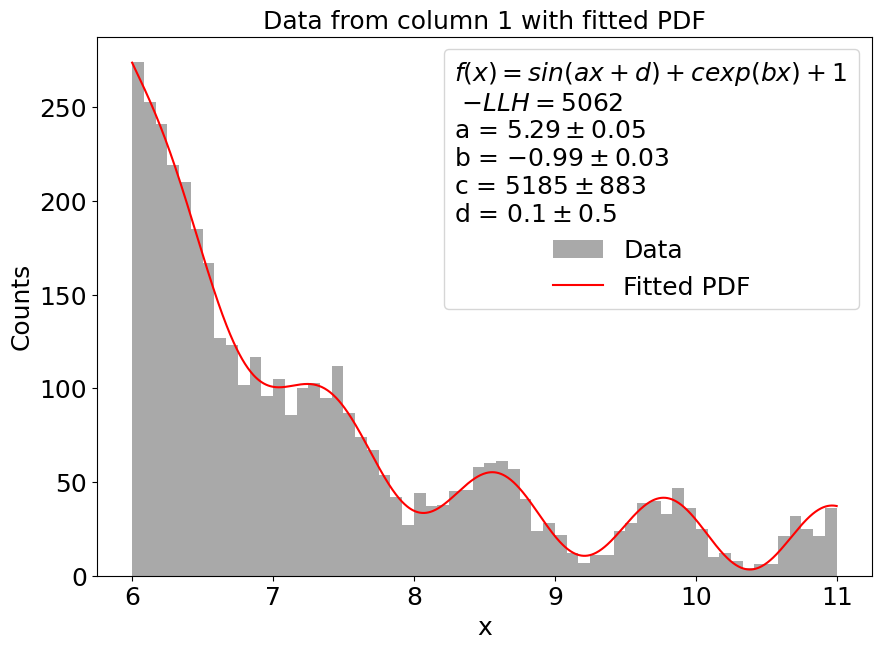

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

xx1 = np.linspace(6, 11, 1000)
xmin1 = 6
xmax1 = 11
binwidth1 = (xmax1 - xmin1) / 60
ax.hist(x1, bins=60, range=(xmin1, xmax1), color='darkgray', label='Data')

ax.plot(xx1, f8_norm(xx1, *m1.values[:])*len(x1)*binwidth1, 'r-', label='Fitted PDF')
fit_info = [f"$f(x)=sin(ax+d) + cexp(bx) + 1$ \n $-LLH = {m1.fval/2:.0f}$",]
for p, v, e in zip(m1.parameters, m1.values[:], m1.errors[:]):
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

ax.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18);
ax.set_xlabel('x', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Data from column 1 with fitted PDF', fontsize=18);
fig.savefig("1b_1.pdf");

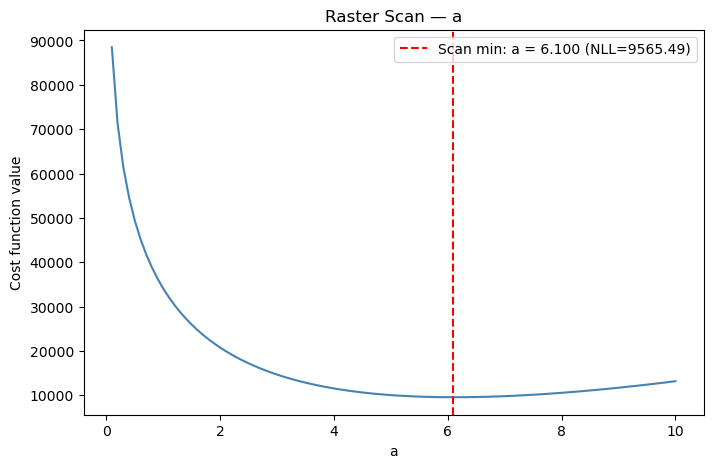

In [13]:
c2 = cost.UnbinnedNLL(x3, f11)
raster_scan(c2, {'a': (0.1,10)}, num_points=100);

In [14]:
m2 = Minuit(c2, lamb=6)
m2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.913e+04                  │              Nfcn = 16               │
│ EDM = 1.26e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ lamb │   6.12    │   0.04    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬─────────┐
│      │    lamb │
├──────┼─────────┤
│ lamb │ 0.00148 │
└──────┴─────────┘

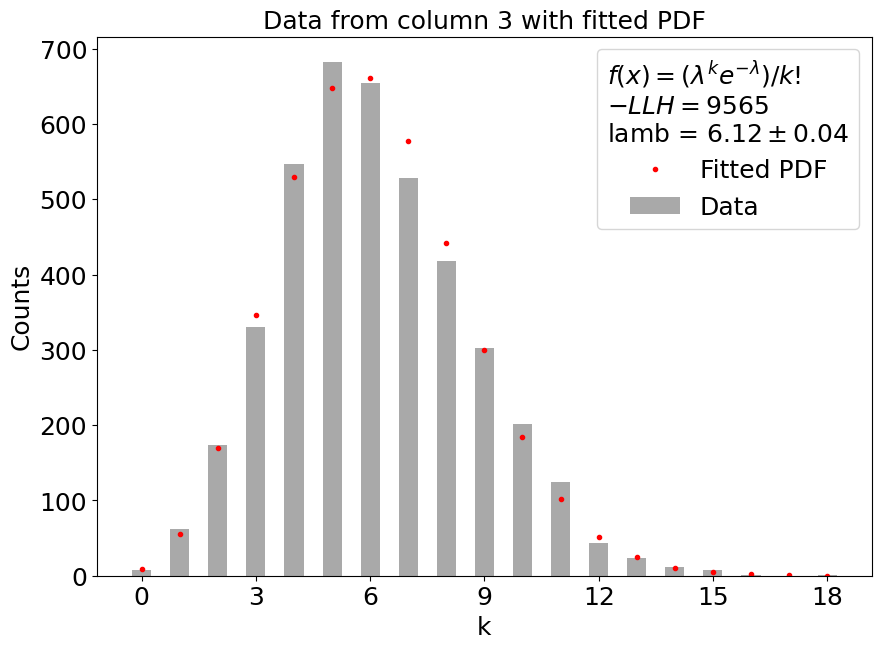

In [20]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(10, 7))
xx2 = np.arange(0, 19)
ax.bar(np.unique(x3), np.unique(x3, return_counts=True)[1], width=0.5, color='darkgray', label='Data')

ax.plot(xx2, f11(xx2, m2.values['lamb'])*len(x3), 'r.', label='Fitted PDF')
fit_info = [rf"$f(x)=(\lambda^k e^{{-\lambda}})/k!$" + "\n" + f"$-LLH = {m2.fval/2:.0f}$",]
for p, v, e in zip(m2.parameters, m2.values[:], m2.errors[:]):
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

ax.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18);
ax.set_xlabel('k', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('Data from column 3 with fitted PDF', fontsize=18);
fig.savefig("1b_2.pdf");

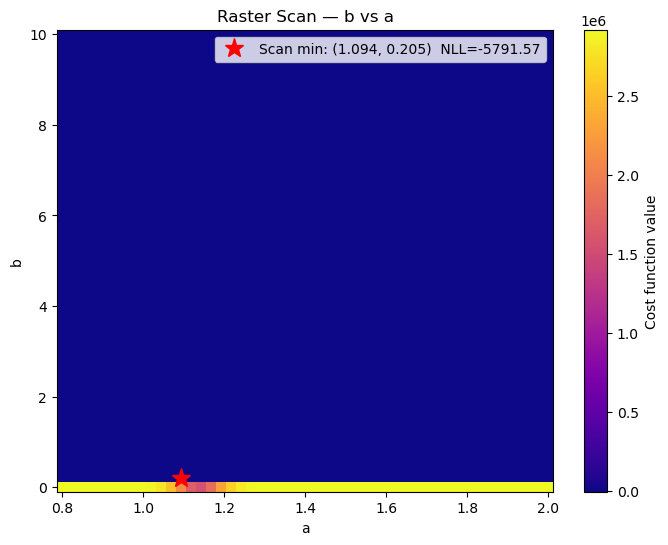

In [16]:
def f9_norm(x, a, b):
    N, _ = quad(lambda t: f9(t, a, b), np.min(x4), np.max(x4))
    if N == 0:
        return np.zeros_like(x)
    return f9(x, a, b) / N
c3 = cost.UnbinnedNLL(x4, f9_norm)
raster_scan(c3, {'a': (0.8, 2), 'b': (0.001,10)}, num_points=50);

In [17]:
c3 = cost.UnbinnedNLL(x4, f9_norm)
m3 = Minuit(c3, a = 1.094, b=0.205)
m3.limits['a'] = (1, 1.3)
m3.limits['b'] = (0.01, 0.05)
m3.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.488e+04                 │              Nfcn = 87               │
│ EDM = 8.73e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  1.1385   │  0.0006   │            │            │    1    │   1.3   │       │
│ 1 │ b    │  40.2e-3  │  0.5e-3   │            │            │  0.01   │  0.05   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 3.99e-07 -0.01e-6 │
│ b │ -0.01e-6 2.16e-07 │
└───┴───────────────────┘

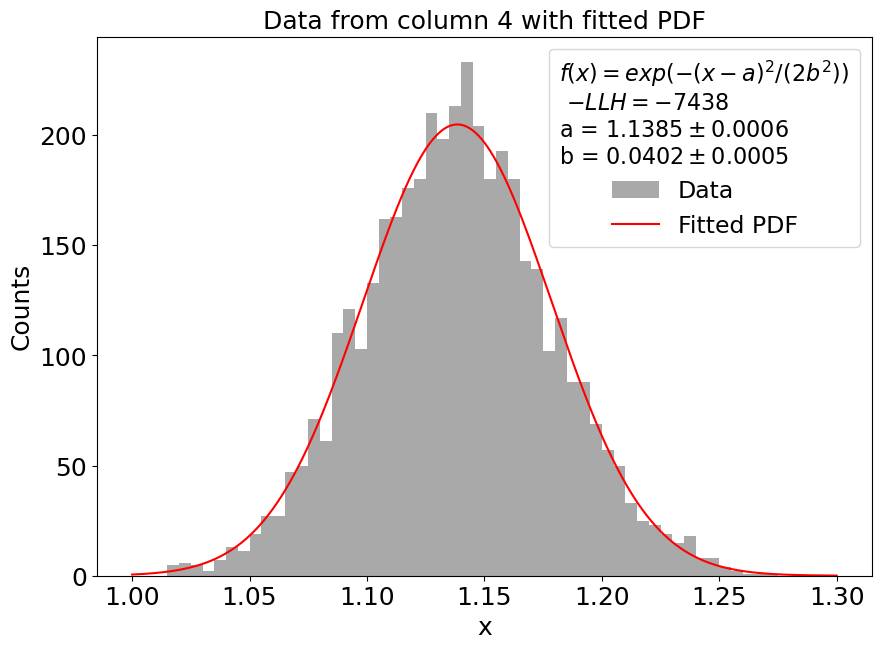

In [19]:


fig, ax = plt.subplots(figsize=(10, 7))
xx3 = np.linspace(1, 1.3, 1000)
xmin3 = 1
xmax3 = 1.3
Nbins = 60
binwidth3 = (xmax3 - xmin3) / Nbins
ax.hist(x4, bins=Nbins, range=(xmin3, xmax3), color='darkgray', label='Data')
ax.plot(xx3, f9_norm(xx3, *m3.values[:])*len(x4)*binwidth3, 'r-', label='Fitted PDF')
fit_info = [f"$f(x)=exp(-(x-a)^2/(2b^2))$ \n $-LLH = {m3.fval/2:.0f}$",]
for p, v, e in zip(m3.parameters, m3.values[:], m3.errors[:]):
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

ax.legend(title="\n".join(fit_info), fontsize=17, title_fontsize = 16);
ax.set_xlabel('x', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Data from column 4 with fitted PDF', fontsize=18)
fig.savefig("1b_3.pdf");

## Bootstraping

In [106]:
r = np.random

def sampler(seed, data, func, params, cont=True):
    r.seed(seed)
    xmin = np.min(data)
    xmax = np.max(data)
    ymax = np.max(func(data, *params))
    Npoints = len(data)
    samples = np.zeros(Npoints)
    for i in range(Npoints):
        while True:
            if cont:
                x_test = r.uniform(xmin, xmax)
            else:
                x_test = r.randint(xmin, xmax+1)
            y_test = r.uniform(0, ymax)
            if (y_test < func(x_test, *params)):
                break
                
        samples[i] = x_test
    return samples


In [107]:
def paramBoot(Nexp, data, func, params, paramNames, cont=True):

    vals = np.zeros((Nexp, len(params)))

    for i in range(Nexp):

        dataMC = sampler(i, data, func, params, cont)

        cfit = cost.UnbinnedNLL(dataMC, func)

        mfit = Minuit(cfit, *params)

        mfit.migrad()

        vals[i] = mfit.values[:]
    lower_p = 15.865
    upper_p = 84.135
    for j in range(len(params)):
        paramLow, paramHigh = np.percentile(vals[:,j], [lower_p, upper_p])
        paramFit = params[j]
        upper = paramHigh - paramFit
        lower = paramFit - paramLow
        print(f"Best fit value for {paramNames[j]} = {paramFit:.4f} + {upper:.4f} - {lower:.4f}")

In [108]:
paramBoot(100, x1, f8_norm, m1.values[:], m1.parameters)
paramBoot(100, x3, f11, m2.values[:], m2.parameters, cont=False)
paramBoot(100, x4, f9_norm, m3.values[:], m3.parameters)

Best fit value for a = 5.2906 + 0.0442 - 0.0591
Best fit value for b = -0.9859 + 0.0293 - 0.0354
Best fit value for c = 5184.9461 + 1221.7491 - 920.1718
Best fit value for d = 0.0767 + 0.5520 - 0.4331
Best fit value for lamb = 6.1176 + 0.0406 - 0.0294
Best fit value for a = 1.1385 + 0.0005 - 0.0005
Best fit value for b = 0.0402 + 0.0004 - 0.0005


## KS

In [61]:
from scipy.stats import ks_2samp

def KS_tester(data, func, params, cont=True):     
    samples = sampler(data, func, params, cont)
    p_ks = ks_2samp(data, samples)[1]
    return p_ks

In [62]:
px1 = KS_tester(x1, f8_norm, m1.values[:])
px3 = KS_tester(x3, f11, m2.values[:], cont=False)
px4 = KS_tester(x4, f9_norm, m3.values[:])

100%|██████████| 4121/4121 [00:00<00:00, 5073.56it/s]


In [110]:
from scipy.stats import norm
print(px1, px3, px4)
z = norm.ppf(1 - px1/2)
print(z)

0.2559554634977279 0.8982017035836324 0.8254609898057784
1.1360026302599207
